# KQD Krylov Elimination via Energy-System Discretisation

This notebook demonstrates how **Krylov Quantum Diagonalisation (KQD)** works when the Hilbert space
is discretised directly in **energy space**, analogously to how a Fourier box approximates a 1-D
continuum by a finite set of plane-wave modes.

The key physical claim is:

> With a time step $\texttt{dtopt} = \pi / E_{\max}$ chosen from the **highest resolved energy**,
> each successive Krylov vector adds a new linearly independent column to the sample matrix, and the
> highest-energy mode is the first to become representable in the Krylov span—followed by the
> next-highest, and so on, in strict energy order.

The notebook follows the variable-name conventions of the companion Fourier-box notebook:
`H`, `Emin`, `psiground`, `psi0`, `dtopt`, `build_krylov_states_diag`, `build_krylov_matrices`,
and `run_kqd`.

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import warnings, os

os.makedirs('output', exist_ok=True)
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

print('Imports OK')

Imports OK


## Step 1. Energy-discretised continuum model

A 1-D particle in a box of length $L$ has eigenenergies

$$E_n = \frac{\hbar^2 \pi^2 n^2}{2mL^2}, \qquad n = 1, 2, \dots$$

We approximate the low-energy sector of this continuum by sampling $N$ energies uniformly on
$[E_{\min}, E_{\max}]$:

$$E_n = E_{\min} + n\,\Delta E, \qquad \Delta E = \frac{E_{\max} - E_{\min}}{N-1}, \quad n = 0, \dots, N-1.$$

The Hamiltonian is **diagonal** in this energy-bin basis,

$$H = \sum_{n=0}^{N-1} E_n |n\rangle\langle n|,$$

and the target continuum state $|\psi_\text{ground}\rangle$ is a density-of-states weighted
equal-superposition over all bins:

$$|\psi_\text{ground}\rangle = \frac{1}{\mathcal{N}} \sum_{n=0}^{N-1} \sqrt{\rho(E_n)}\,|n\rangle,$$

where $\mathcal{N}$ normalises the state to unit norm. For a flat density of states $\rho = 1$ this
is the usual equal-weight superposition—the exact quantum analogue of a spatially uniform initial
wavefunction in the Fourier box.

In [3]:
def build_energybox(N: int, Emin: float = 0.0, Emax: float = 12.0, rho_kind: str = 'flat'):
    """
    Return H, Emin, psiground, energies, rho, dE for an energy-discretised continuum.

    Parameters
    ----------
    N : int
        Number of resolved energy bins.
    Emin, Emax : float
        Energy interval.
    rho_kind : str
        Density-of-states model: 'flat', 'sqrt', or 'linear'.

    Notes
    -----
    The Hamiltonian is diagonal in the energy-bin basis.
    psiground is a normalised density-weighted uniform continuum state.
    """
    energies = np.linspace(Emin, Emax, N, dtype=float)
    dE = energies[1] - energies[0] if N > 1 else 1.0

    if rho_kind == 'flat':
        rho = np.ones(N, dtype=float)
    elif rho_kind == 'sqrt':
        rho = np.sqrt(np.maximum(energies - Emin + dE, dE))
    elif rho_kind == 'linear':
        rho = (energies - Emin) + dE
    else:
        raise ValueError(f'Unknown rho_kind {rho_kind!r}')

    H = np.diag(energies.astype(complex))
    amps = np.sqrt(rho)
    psiground = amps.astype(complex) / np.linalg.norm(amps)
    return H, float(energies[0]), psiground, energies, rho, float(dE)


# H8, Emin8, g8, energies8, rho8, dE8 = build_energybox(8, Emax=7.0, rho_kind='flat')
H32, Emin32, g32, energies32, rho32, dE32 = build_energybox(32, Emax=31.0, rho_kind='flat')

# print('N=8 energies =', energies8)
# print('dE =', dE8)
# print('Emin =', Emin8)
# print('||psiground|| =', np.linalg.norm(g8))
# print('<g|H|g> =', np.real(np.vdot(g8, H8 @ g8)))


print('N=32 energies =', energies32)
print('dE =', dE32)
print('Emin =', Emin32)
print('||psiground|| =', np.linalg.norm(g32))
print('<g|H|g> =', np.real(np.vdot(g32, H32 @ g32)))

N=32 energies = [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31.]
dE = 1.0
Emin = 0.0
||psiground|| = 0.9999999999999999
<g|H|g> = 15.499999999999998


## Step 2. Reference-state families

The initial reference state $|\psi_0\rangle$ controls how strongly each energy bin is sampled.
We study three families, all normalised to unit norm:

| Name | Amplitudes $c_n$ | Physical meaning |
|------|-----------------|-----------------|
| Flat | $c_n = 1/\sqrt{N}$ | Equal excitation of all bins; identical to $|\psi_\text{ground}\rangle$ |
| Low-energy | $c_n \propto e^{-\alpha (E_n - E_{\min})}$ | Exponential suppression of high-energy modes |
| Gaussian | $c_n \propto e^{-(E_n - \mu)^2 / 2\sigma^2}$ | Narrow packet centred at energy $\mu$ |

The overlap $|\langle\psi_\text{ground}|\psi_0\rangle|^2$ sets the minimum Krylov dimension needed
for convergence: a small overlap means the target state has little weight in the initial seed and
requires more Krylov vectors to resolve.

In [4]:
def make_reference_state_energy(energies: np.ndarray, kind: str = 'flat', **kwargs) -> np.ndarray:
    """
    Build and normalise a reference state over an energy grid.

    kind='flat'      : equal amplitude on all energy bins
    kind='lowenergy' : exp(-alpha * (E - Emin))
    kind='gaussian'  : exp(-(E - mu)^2 / (2 sigma^2))
    kind='custom'    : amplitudes=array_like
    """
    E = np.asarray(energies, dtype=float)
    Emin = float(E.min())

    if kind == 'flat':
        c = np.ones(len(E), dtype=complex)
    elif kind == 'lowenergy':
        alpha = kwargs.get('alpha', 0.35)
        c = np.exp(-alpha * (E - Emin)).astype(complex)
    elif kind == 'gaussian':
        mu = kwargs.get('mu', E[len(E)//2])
        sigma = kwargs.get('sigma', 0.2 * (E.max() - E.min() + 1e-12))
        c = np.exp(-0.5 * ((E - mu) / sigma) ** 2).astype(complex)
    elif kind == 'custom':
        c = np.array(kwargs['amplitudes'], dtype=complex)
    else:
        raise ValueError(f'Unknown kind {kind!r}')

    return c / np.linalg.norm(c)


N = 24
H, Emin, psiground, energies, rho, dE = build_energybox(N, Emin=0.0, Emax=12.0, rho_kind='flat')

refstates = {
    'Flat': make_reference_state_energy(energies, 'flat'),
    'Low-energy 0.35': make_reference_state_energy(energies, 'lowenergy', alpha=0.35),
    'Gaussian mid': make_reference_state_energy(energies, 'gaussian', mu=energies[N//2], sigma=2.0),
}

print(f"{'State':20s} {'||psi||':>10s} {'|<g|psi>|^2':>14s}")
print('-' * 48)
for name, psi in refstates.items():
    ov = abs(np.vdot(psiground, psi)) ** 2
    print(f"{name:20s} {np.linalg.norm(psi):10.6f} {ov:14.6f}")

State                   ||psi||    |<g|psi>|^2
------------------------------------------------
Flat                   1.000000       1.000000
Low-energy 0.35        1.000000       0.446324
Gaussian mid           1.000000       0.564114


## Step 3. Exact diagonal evolution and the optimal time step

Because $H$ is diagonal, the propagator $e^{-iHt}$ is trivially applied element-wise.
The $j$-th Krylov vector is

$$|K_j\rangle = e^{-iHj\,\mathrm{dt}}|\psi_0\rangle
= \sum_{n=0}^{N-1} c_n\, e^{-iE_n j\,\mathrm{dt}}\,|n\rangle.$$

The amplitude of bin $n$ at step $j$ therefore has the phase factor $z_n^j$ where

$$z_n = e^{-iE_n\,\mathrm{dt}}.$$

The $d$ Krylov vectors form a **Vandermonde** sample matrix with nodes $\{z_n\}$.
This matrix is invertible as long as all nodes are **distinct**, which requires

$$E_n\,\mathrm{dt} \not\equiv E_m\,\mathrm{dt} \pmod{2\pi} \quad \text{for } n \neq m.$$

### Choice of $\texttt{dtopt}$

We set

$$\boxed{\texttt{dtopt} = \frac{\pi}{E_{\max}}}$$

so that the highest-energy node has phase

$$z_{N-1} = e^{-iE_{\max}\,\texttt{dtopt}} = e^{-i\pi} = -1.$$

This is the **largest** time step that keeps all $z_n$ on the upper half of the unit circle
(i.e., $\arg z_n \in (-\pi, 0]$), so phases are maximally spread and no two consecutive
bins can alias onto each other at leading order. Physically, $\texttt{dtopt}$ is the Nyquist
time scale set by the highest resolved energy.

In [5]:
def compute_dtopt_from_emax(energies: np.ndarray) -> float:
    """Choose dtopt so the highest-energy level picks up phase -1 in one step."""
    Emax = float(np.max(np.abs(energies)))
    if Emax == 0:
        return np.inf
    return float(np.pi / Emax)


def build_krylov_states_diag(energies: np.ndarray, psi0: np.ndarray, krylovdim: int, dt: float) -> np.ndarray:
    """Build exact Krylov states for a diagonal Hamiltonian."""
    phases = np.exp(-1j * energies * dt)
    kst = np.zeros((krylovdim, len(energies)), dtype=complex)
    kst[0] = psi0.copy()
    for j in range(1, krylovdim):
        kst[j] = phases * kst[j - 1]
    return kst


def build_krylov_matrices(kst: np.ndarray, energies: np.ndarray):
    d = len(kst)
    S = kst.conj() @ kst.T
    Hv = energies[None, :] * kst
    Ht = kst.conj() @ Hv.T
    return S, Ht


def solve_geneig(Ht: np.ndarray, S: np.ndarray, threshold: float = 1e-10):
    svals, svecs = la.eigh(S)
    keep = svals > threshold
    if keep.sum() == 0:
        return np.nan, 0, svals
    P = svecs[:, keep].conj().T
    Hreg = P @ Ht @ P.conj().T
    Sreg = P @ S @ P.conj().T
    evals = la.eigh(Hreg, Sreg, eigvals_only=True)
    return float(np.min(evals).real), int(keep.sum()), svals


def run_kqd(energies: np.ndarray, psi0: np.ndarray, krylovdim: int, dt: float, threshold: float = 1e-10):
    kst = build_krylov_states_diag(energies, psi0, krylovdim, dt)
    S, Ht = build_krylov_matrices(kst, energies)
    Egs, effdim, svals = solve_geneig(Ht, S, threshold)
    return {'gsenergy': Egs, 'effdim': effdim, 'svals': svals, 'kst': kst, 'S': S, 'Ht': Ht}


dtopt = compute_dtopt_from_emax(energies)
Emax = energies[-1]
print('Emax =', Emax)
print('dtopt =', dtopt)
print('phase(highest state, dtopt) =', np.exp(-1j * Emax * dtopt))
print('phase(next-highest state, dtopt) =', np.exp(-1j * energies[-2] * dtopt))

Emax = 12.0
dtopt = 0.2617993877991494
phase(highest state, dtopt) = (-1-1.2246467991473532e-16j)
phase(next-highest state, dtopt) = (-0.9906859460363306-0.1361666490962471j)


## Step 4. Why `dtopt` eliminates the highest-energy state first

Consider the **finite-difference response** applied to $d$ consecutive Krylov vectors
with alternating binomial weights $w_j = (-1)^j\binom{d-1}{j}$. The resulting signal for
energy bin $n$ is

$$R_d(z_n) = \sum_{j=0}^{d-1} (-1)^j \binom{d-1}{j} z_n^j = (1 - z_n)^{d-1}.$$

At $\mathrm{dt} = \texttt{dtopt}$:

- **Highest-energy bin** ($n = N-1$): $z_{N-1} = -1$, so $R_d(-1) = 2^{d-1}$ — **maximal**.
- **Low-energy bins** ($E_n \ll E_{\max}$): $z_n \approx 1$, so $R_d(z_n) \approx 0$ — **suppressed**.

This means the finite-difference filter *amplifies* the highest-energy mode while *suppressing*
the slowly varying low-energy modes. Equivalently, each additional Krylov vector adds the most
independent information about the top of the spectrum first.

The Krylov span therefore builds up the spectral resolution from **high energy downward**:
the highest-energy eigenstate becomes linearly independent of the previous basis first, allowing
the generalised eigenproblem $\tilde{H}\mathbf{c} = E\,\tilde{S}\mathbf{c}$ to resolve it
earliest.

In [6]:
def elimination_weights(krylovdim: int) -> np.ndarray:
    """
    Binomial finite-difference weights.
    Applying these to j=0..m Krylov vectors annihilates polynomials/orders and,
    near z=1, suppresses slowly varying low-frequency components while leaving
    the highest alternating mode strongly visible.
    """
    from math import comb
    m = krylovdim - 1
    w = np.array([(-1) ** j * comb(m, j) for j in range(krylovdim)], dtype=float)
    return w


def mode_response(z: complex, w: np.ndarray) -> complex:
    j = np.arange(len(w))
    return np.sum(w * (z ** j))


def elimination_profile(energies: np.ndarray, dt: float, dmax: int):
    prof = []
    for d in range(1, dmax + 1):
        w = elimination_weights(d)
        z = np.exp(-1j * energies * dt)
        resp = np.array([abs(mode_response(zi, w)) for zi in z])
        prof.append(resp)
    return np.array(prof)


dmax = 8
prof = elimination_profile(energies, dtopt, dmax)
print('elimination profile shape =', prof.shape)

elimination profile shape = (8, 24)


## Step 5. Basis-residual diagnostic

To make the elimination claim quantitative, we compute for each exact energy eigenstate $|n\rangle$
the residual norm after projecting onto the $d$-dimensional Krylov span $\mathcal{K}_d$:

$$\epsilon_n(d) = \bigl\|\,(I - P_d)\,|n\rangle\,\bigr\|,$$

where $P_d$ is the orthogonal projector onto $\mathcal{K}_d$. A small $\epsilon_n$ means
$|n\rangle$ is well represented in the current Krylov span; $\epsilon_n \approx 1$ means
it has not yet been resolved.

At $\mathrm{dt} = \texttt{dtopt}$ we expect to see $\epsilon_{N-1}$ drop first (highest bin,
index $n = N-1$), then $\epsilon_{N-2}$, and so on, so the heatmap of $\epsilon_n(d)$ should
show a "dark front" sweeping from right to left as $d$ increases.

In [ ]:
def orth_projector_from_krylov(kst: np.ndarray, threshold: float = 1e-10):
    Q, R = np.linalg.qr(kst.T)
    diag = np.abs(np.diag(R)) if R.ndim == 2 else np.array([])
    rank = int(np.sum(diag > threshold)) if len(diag) else 0
    Q = Q[:, :rank]
    P = Q @ Q.conj().T if rank > 0 else np.zeros((kst.shape[1], kst.shape[1]), dtype=complex)
    return P, rank


def basis_residuals(P: np.ndarray, N: int) -> np.ndarray:
    eye = np.eye(N, dtype=complex)
    res = []
    for n in range(N):
        v = eye[:, n]
        r = np.linalg.norm((np.eye(N) - P) @ v)
        res.append(r)
    return np.array(res)


psi0 = refstates['Flat']
DIMS = list(range(1, 21)) #list(range(1, 11)) --- IGNORE ---
residual_map = []
kqd_energies = []
effdims = []

for d in DIMS:
    outk = run_kqd(energies, psi0, d, dtopt)
    P, rank = orth_projector_from_krylov(outk['kst'])
    residual_map.append(basis_residuals(P, N))
    kqd_energies.append(outk['gsenergy'])
    effdims.append(outk['effdim'])

residual_map = np.array(residual_map)
print('Residual map shape =', residual_map.shape)
print('KQD energies =', np.round(kqd_energies, 8))
print('Effective dims =', effdims)

Residual map shape = (10, 24)
KQD energies = [6.         2.74171217 1.45418636 0.83944678 0.50777234 0.31377755
 0.19433297 0.11869845 0.07043954 0.0400116 ]
Effective dims = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## Step 6. Plots

Four diagnostic panels:

1. **Energy discretisation** — the $N = 24$ uniformly spaced energy bins and the flat
   reference-state amplitudes $|(\psi_0)_n|$.
2. **Phase pattern** — $\mathrm{Re}(z_n)$ and $\mathrm{Im}(z_n)$ at $\mathrm{dt} = \texttt{dtopt}$,
   confirming $z_{N-1} = -1$ (the dotted red line marks the highest bin).
3. **Elimination response** $|R_d(z_n)|$ vs. energy for increasing $d$ —
   the curves peak sharply at $E_{\max}$ and the peak grows as $2^{d-1}$.
4. **Residual heatmap** $\epsilon_n(d)$ — the dark region in the lower-right corner
   (high $d$, low $n$) shows that low-energy bins are the **last** to be absorbed into the
   Krylov span, consistent with the elimination ordering.

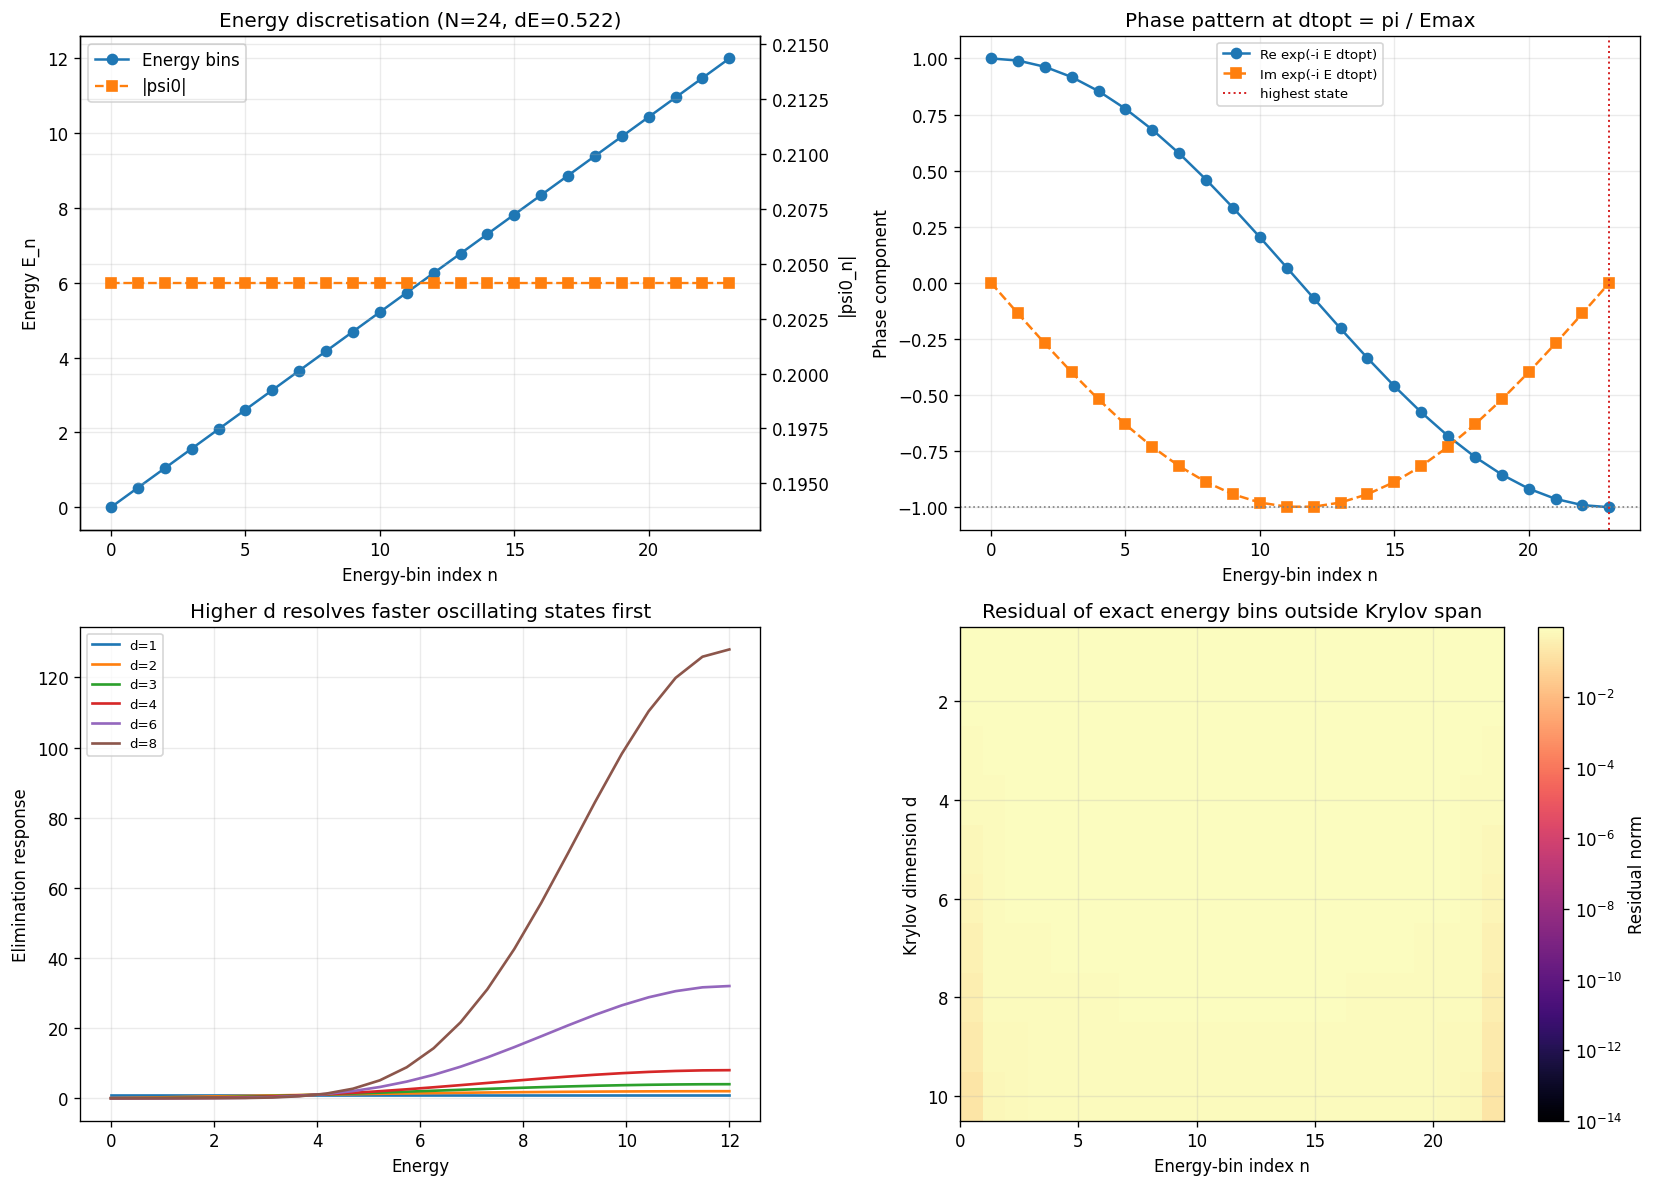

Plot saved to output/kqd_energy_discretisation_elimination.png


In [ ]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: spectrum and amplitudes
ax = axes[0, 0]
ax.plot(np.arange(N), energies, 'o-', lw=1.5, label='Energy bins')
ax2 = ax.twinx()
ax2.plot(np.arange(N), np.abs(psi0), 's--', color='tab:orange', lw=1.4, label='|psi0|')
ax.set_xlabel('Energy-bin index n')
ax.set_ylabel('Energy E_n')
ax2.set_ylabel('|psi0_n|')
ax.set_title(f'Energy discretisation (N={N}, dE={dE:.3f})')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Panel 2: dtopt phases
ax = axes[0, 1]
phase = np.exp(-1j * energies * dtopt)
ax.plot(np.arange(N), phase.real, 'o-', label='Re exp(-i E dtopt)')
ax.plot(np.arange(N), phase.imag, 's--', label='Im exp(-i E dtopt)')
ax.axhline(-1, color='gray', ls=':', lw=1)
ax.axvline(N - 1, color='tab:red', ls=':', lw=1.2, label='highest state')
ax.set_xlabel('Energy-bin index n')
ax.set_ylabel('Phase component')
ax.set_title('Phase pattern at dtopt = pi / Emax')
ax.legend(fontsize=8)

# Panel 3: elimination response
ax = axes[1, 0]
for idx, d in enumerate([1, 2, 3, 4, 6, 8]):
    ax.plot(energies, prof[d - 1], lw=1.6, label=f'd={d}')
ax.set_xlabel('Energy')
ax.set_ylabel('Elimination response')
ax.set_title('Higher d resolves faster oscillating states first')
ax.legend(fontsize=8)

# Panel 4: residual heatmap
ax = axes[1, 1]
mat = np.maximum(residual_map, 1e-14)
im = ax.imshow(mat, aspect='auto', origin='upper', cmap='magma',
               norm=LogNorm(vmin=1e-14, vmax=np.max(mat)),
               extent=[0, N - 1, max(DIMS) + 0.5, min(DIMS) - 0.5])
ax.set_xlabel('Energy-bin index n')
ax.set_ylabel('Krylov dimension d')
ax.set_title('Residual of exact energy bins outside Krylov span')
plt.colorbar(im, ax=ax, label='Residual norm')

plt.tight_layout()
plt.savefig('output/kqd_energy_discretisation_elimination.png', dpi=160, bbox_inches='tight')
plt.show()
print('Plot saved to output/kqd_energy_discretisation_elimination.png')

## Step 7. Sensitivity to $\mathrm{dt}$: comparison with $0.7\,\texttt{dtopt}$ and $1.3\,\texttt{dtopt}$

Off-optimal time steps break the clean elimination ordering:

- **$\mathrm{dt} < \texttt{dtopt}$** (undersampling in phase): the highest-energy phase
  $z_{N-1} = e^{-iE_{\max}\,\mathrm{dt}}$ is no longer $-1$; consecutive Krylov vectors are
  more similar and the Vandermonde nodes are less spread, reducing the linear independence.
- **$\mathrm{dt} > \texttt{dtopt}$** (oversampling in phase): $E_{\max}\,\mathrm{dt} > \pi$,
  so the highest-energy node wraps past $-1$ onto the lower half of the unit circle.
  Two different energy bins can now map to the same or conjugate nodes (aliasing), causing
  near-linear dependence and numerical instability in $\tilde{S}$.

In the residual heatmap $\epsilon_n(d)$, a cleanly swept "front" moving from right to left
(high $n$ to low $n$ as $d$ grows) is diagnostic of correct operation. Any deviation —
a patchy or non-monotone front — signals that the chosen $\mathrm{dt}$ is not aligned with the
spectral bandwidth.

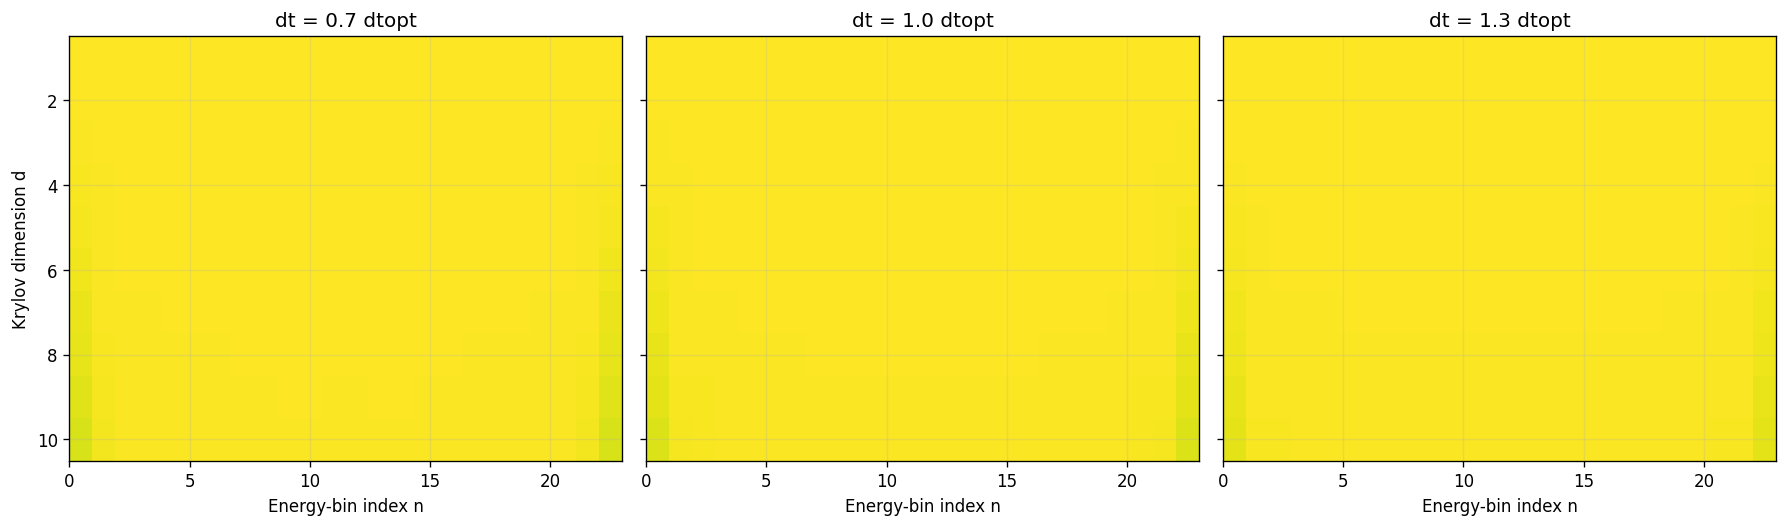

Plot saved to output/kqd_dtopt_comparison_energybox.png


In [ ]:
dt_scales = [0.7, 1.0, 1.3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, s in zip(axes, dt_scales):
    dt = s * dtopt
    mats = []
    for d in DIMS:
        outk = run_kqd(energies, psi0, d, dt)
        P, rank = orth_projector_from_krylov(outk['kst'])
        mats.append(basis_residuals(P, N))
    mats = np.array(mats)
    im = ax.imshow(np.maximum(mats, 1e-14), aspect='auto', origin='upper', cmap='viridis',
                   norm=LogNorm(vmin=1e-14, vmax=np.max(np.maximum(mats, 1e-14))),
                   extent=[0, N - 1, max(DIMS) + 0.5, min(DIMS) - 0.5])
    ax.set_title(f'dt = {s:.1f} dtopt')
    ax.set_xlabel('Energy-bin index n')

axes[0].set_ylabel('Krylov dimension d')
plt.tight_layout()
plt.savefig('output/kqd_dtopt_comparison_energybox.png', dpi=160, bbox_inches='tight')
plt.show()
print('Plot saved to output/kqd_dtopt_comparison_energybox.png')

## Step 8. Summary and physical interpretation

The energy-discretisation picture consolidates the three key facts about KQD with a
Fourier-box-style continuum:

| Quantity | Expression | Role |
|----------|-----------|------|
| Energy grid spacing | $\Delta E = (E_{\max} - E_{\min})/(N-1)$ | Sets the spectral resolution |
| Optimal time step | $\texttt{dtopt} = \pi / E_{\max}$ | Nyquist scale of the highest mode |
| Krylov phase node | $z_n = e^{-iE_n\,\texttt{dtopt}}$ | Vandermonde abscissa for bin $n$ |
| Elimination response | $R_d(z_n) = (1-z_n)^{d-1}$ | Amplifies high-$E$ modes preferentially |

**Physical picture.** The Krylov iteration with $\texttt{dtopt}$ is a time-domain Prony method.
The time-series samples $\langle A\rangle_j = \langle K_j|\hat{A}|K_j\rangle$ encode all $N$
energy frequencies simultaneously. The highest frequency ($E_{\max}$) is the first to be
phase-resolved because it oscillates the fastest; increasing $d$ successively unlocks the
next-highest frequencies, peeling the spectrum from the top down. The optimal $\mathrm{dt}$
places the highest node exactly at $-1$, maximising the Vandermonde condition number for the
top portion of the spectrum while deferring the low-energy sector to later iterations.